In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os

/opt/anaconda3/envs/timedrl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create OOD datasets

In [3]:
def filter_and_save(split_name, base_path="../dataset/classification/WISDM/"):
    # Load the original data
    load_path = os.path.join(base_path, f"{split_name}_orig.pt")
    data = torch.load(load_path)
    
    samples = data["samples"]
    labels = data["labels"]

    # Create mask: keep everything EXCEPT labels 1 and 4
    # mask = (labels != 1) & (labels != 4)

    # Create mask: Keep ONLY labels 1 and 4 (the OOD classes)
    mask = (labels == 1) | (labels == 4)

    filtered_dataset = {
        "samples": samples[mask],
        "labels": labels[mask]
    }

    # Save the filtered version
    save_path = os.path.join(base_path, f"{split_name}.pt")
    torch.save(filtered_dataset, save_path)
    
    print(f"Processed {split_name}: {len(samples)} -> {len(filtered_dataset['samples'])} samples.")



splits = ["train", "test", "val"]
for s in splits:
    filter_and_save(s)

Processed train: 2617 -> 1113 samples.
Processed test: 819 -> 341 samples.
Processed val: 655 -> 275 samples.


In [2]:
df = pd.read_csv('../dataset/forecasting/ETT-small/ETTh1.csv')

In [3]:
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [4]:
df.shape

(17420, 8)

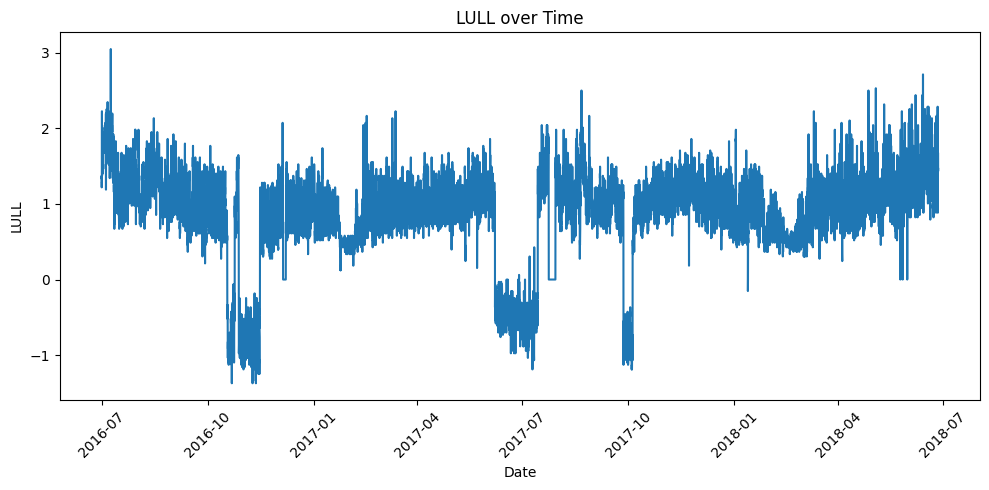

In [5]:
col_name = "LULL"

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10,5))
plt.plot(df["date"], df[col_name])

plt.xlabel("Date")
plt.ylabel(col_name)
plt.title(f"{col_name} over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
train_dataset = torch.load("../dataset/classification/WISDM/train.pt")

In [16]:
len(train_dataset.get('samples')[0])

256

In [19]:
train_dataset.get('samples')[5]

tensor([[  8.4700,  -0.0400,  -2.8700],
        [ 10.6500,  -0.3800,   0.8000],
        [  8.0800,   0.8000,   0.9100],
        [  6.4700,   1.5000,   4.1800],
        [  8.2000,   1.0400,   2.4100],
        [  5.1300,  -0.1900,   0.3800],
        [  2.6000,   0.8000,  -0.5300],
        [  2.9800,   1.6500,  -0.3400],
        [  7.2100,   1.8400,  -1.5000],
        [ 14.1800,   4.3300,  -0.4600],
        [ 17.6900,   2.6400,   4.1000],
        [ 14.5200,   1.9500,   4.1800],
        [ 11.3300,   1.4200,   1.6900],
        [  6.8200,  -2.7200,   2.9100],
        [  0.2300,  -0.6100,   5.9000],
        [  1.8400,  -1.3100,   4.5900],
        [  3.1100,   2.7200,   1.7300],
        [ 16.2800,   6.2800,   0.5000],
        [ 15.9400,   5.2800,   6.0200],
        [ 11.5600,  12.2200,  -2.3700],
        [  2.8300,   6.3600,   9.4900],
        [  3.6400,   4.9400,   0.0400],
        [  8.4300,   3.2600,  -0.1900],
        [ 11.2600,   0.5700,  -0.0400],
        [  5.4800,  -3.1100,   3.4900],


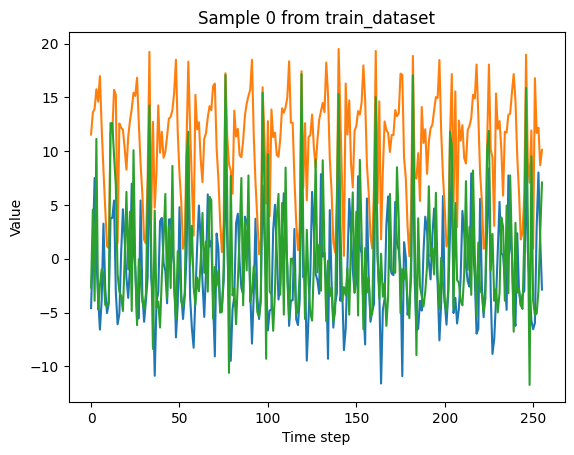

In [17]:
sample = train_dataset.get('samples')[0]

plt.figure()
plt.plot(sample)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Sample 0 from train_dataset")
plt.show()